# QIDS-SR-16 data description and treatment comparisons

This notebook plots the QIDS-SR-16 score distributions and compares pre- and post-treatment changes for the escitalopram and psilocybin groups. Positive change scores indicate symptom improvement.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy import stats

## Data
Insert data frames of QIDS scores when granted access by the Imperial Psychedelic Research Centre

In [ ]:
escitalopram = #Dataframe with rows of data for each escitalopram patient. Each row has (Patient Number, Pre-treatment QIDS score, Post-treatment QIDS score)

escitalopram["Treatment"] = "Escitalopram"

psilocybin = #Dataframe with rows of data for each psilocybin patient. Each row has (Patient Number, Pre-treatment QIDS score, Post-treatment QIDS score)

psilocybin["Treatment"] = "Psilocybin"

data = pd.concat([escitalopram, psilocybin], ignore_index=True)
data["Change"] = data["Pre-treatment"] - data["Post-treatment"]

## QIDS-SR-16 distributions

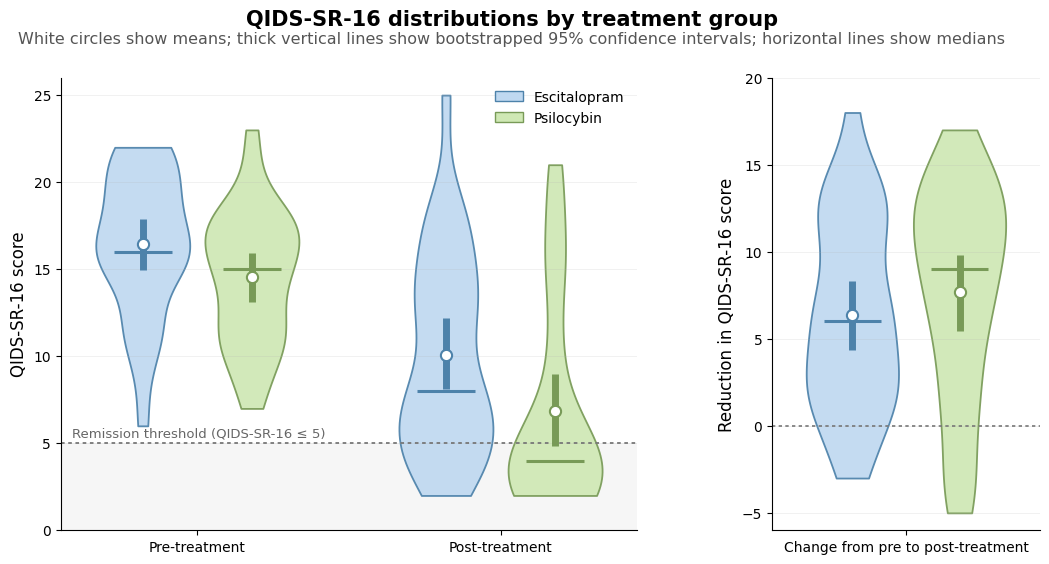

In [3]:
fig, (ax_scores, ax_change) = plt.subplots(
    1,
    2,
    figsize=(11, 6.2),
    gridspec_kw={"width_ratios": [2.15, 1], "wspace": 0.32},
)

for measure_index, (measure, centre) in enumerate([
    ("Pre-treatment", 1),
    ("Post-treatment", 2),
]):
    for treatment_index, (treatment, fill, edge, offset) in enumerate([
        ("Escitalopram", "#BFD8F0", "#4D82AA", -0.18),
        ("Psilocybin", "#CFE8B4", "#789A57", 0.18),
    ]):
        values = data.loc[data["Treatment"] == treatment, measure].to_numpy()
        position = centre + offset

        violin = ax_scores.violinplot(
            values,
            positions=[position],
            widths=0.31,
            showmeans=False,
            showmedians=False,
            showextrema=False,
            bw_method=0.4,
        )
        violin["bodies"][0].set_facecolor(fill)
        violin["bodies"][0].set_edgecolor(edge)
        violin["bodies"][0].set_linewidth(1.3)
        violin["bodies"][0].set_alpha(0.92)

        rng = np.random.default_rng(100 + measure_index * 10 + treatment_index)
        bootstrap_means = rng.choice(
            values,
            size=(10_000, len(values)),
            replace=True,
        ).mean(axis=1)
        lower, upper = np.percentile(bootstrap_means, [2.5, 97.5])

        ax_scores.vlines(position, lower, upper, color=edge, linewidth=5, zorder=5)
        ax_scores.hlines(
            np.median(values),
            position - 0.095,
            position + 0.095,
            color=edge,
            linewidth=2.2,
            zorder=6,
        )
        ax_scores.scatter(
            position,
            values.mean(),
            s=65,
            facecolor="white",
            edgecolor=edge,
            linewidth=1.5,
            zorder=7,
        )


for treatment_index, (treatment, fill, edge, offset) in enumerate([
    ("Escitalopram", "#BFD8F0", "#4D82AA", -0.18),
    ("Psilocybin", "#CFE8B4", "#789A57", 0.18),
]):
    values = data.loc[data["Treatment"] == treatment, "Change"].to_numpy()
    position = 1 + offset

    violin = ax_change.violinplot(
        values,
        positions=[position],
        widths=0.31,
        showmeans=False,
        showmedians=False,
        showextrema=False,
        bw_method=0.4,
    )
    violin["bodies"][0].set_facecolor(fill)
    violin["bodies"][0].set_edgecolor(edge)
    violin["bodies"][0].set_linewidth(1.3)
    violin["bodies"][0].set_alpha(0.92)

    rng = np.random.default_rng(200 + treatment_index)
    bootstrap_means = rng.choice(
        values,
        size=(10_000, len(values)),
        replace=True,
    ).mean(axis=1)
    lower, upper = np.percentile(bootstrap_means, [2.5, 97.5])

    ax_change.vlines(position, lower, upper, color=edge, linewidth=5, zorder=5)
    ax_change.hlines(
        np.median(values),
        position - 0.095,
        position + 0.095,
        color=edge,
        linewidth=2.2,
        zorder=6,
    )
    ax_change.scatter(
        position,
        values.mean(),
        s=65,
        facecolor="white",
        edgecolor=edge,
        linewidth=1.5,
        zorder=7,
    )

ax_scores.axhspan(0, 5, facecolor="#D9D9D9", alpha=0.22, zorder=0)
ax_scores.axhline(5, color="#777777", linestyle=(0, (2, 2)), linewidth=1.3)
ax_scores.text(
    0.02,
    5.35,
    "Remission threshold (QIDS-SR-16 ≤ 5)",
    transform=ax_scores.get_yaxis_transform(),
    fontsize=9.5,
    color="#666666",
)
ax_scores.set_xlim(0.55, 2.45)
ax_scores.set_ylim(0, 26)
ax_scores.set_xticks([1, 2], ["Pre-treatment", "Post-treatment"])
ax_scores.set_ylabel("QIDS-SR-16 score", fontsize=12)
ax_scores.legend(
    handles=[
        Patch(facecolor="#BFD8F0", edgecolor="#4D82AA", label="Escitalopram"),
        Patch(facecolor="#CFE8B4", edgecolor="#789A57", label="Psilocybin"),
    ],
    loc="upper right",
    frameon=False,
)

ax_change.axhline(0, color="#777777", linestyle=(0, (2, 2)), linewidth=1.2)
ax_change.set_xlim(0.55, 1.45)
ax_change.set_ylim(-6, 20)
ax_change.set_xticks([1], ["Change from pre to post-treatment"])
ax_change.set_ylabel("Reduction in QIDS-SR-16 score", fontsize=12)

for axis in (ax_scores, ax_change):
    axis.grid(axis="y", linewidth=0.7, alpha=0.18, zorder=0)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

fig.suptitle(
    "QIDS-SR-16 distributions by treatment group",
    fontsize=15,
    fontweight="semibold",
    y=0.98,
)
fig.text(
    0.5,
    0.925,
    "White circles show means; thick vertical lines show bootstrapped 95% confidence intervals; horizontal lines show medians",
    ha="center",
    fontsize=11.5,
    color="#555555",
)
fig.subplots_adjust(top=0.87, bottom=0.14, left=0.09, right=0.98)

plt.show()

## Mean Tests

In [ ]:
e_pre = escitalopram["Pre-treatment"].to_numpy(dtype=float)
e_post = escitalopram["Post-treatment"].to_numpy(dtype=float)
e_change = e_pre - e_post

p_pre = psilocybin["Pre-treatment"].to_numpy(dtype=float)
p_post = psilocybin["Post-treatment"].to_numpy(dtype=float)
p_change = p_pre - p_post

e_t_test = stats.ttest_rel(e_pre, e_post)
p_t_test = stats.ttest_rel(p_pre, p_post)
e_t_ci = e_t_test.confidence_interval()
p_t_ci = p_t_test.confidence_interval()

between_t_test = stats.ttest_ind(p_change, e_change, equal_var=False)
between_t_ci = between_t_test.confidence_interval()

## Bootstrapped CIs

In [ ]:

bootstrap = {}

for treatment, change, seed in [
    ("Escitalopram", e_change, 101),
    ("Psilocybin", p_change, 102),
]:
    rng = np.random.default_rng(seed)

    bootstrap_means = rng.choice(
        change,
        size=(100_000, len(change)),
        replace=True,
    ).mean(axis=1)

    centred_change = change - change.mean()
    null_means = rng.choice(
        centred_change,
        size=(100_000, len(change)),
        replace=True,
    ).mean(axis=1)

    bootstrap[treatment] = {
        "CI": np.percentile(bootstrap_means, [2.5, 97.5]),
        "p": (np.sum(np.abs(null_means) >= abs(change.mean())) + 1) / 100_001,
    }


rng = np.random.default_rng(103)

bootstrap_differences = (
    rng.choice(p_change, size=(100_000, len(p_change)), replace=True).mean(axis=1)
    - rng.choice(e_change, size=(100_000, len(e_change)), replace=True).mean(axis=1)
)

null_differences = (
    rng.choice(
        p_change - p_change.mean(),
        size=(100_000, len(p_change)),
        replace=True,
    ).mean(axis=1)
    - rng.choice(
        e_change - e_change.mean(),
        size=(100_000, len(e_change)),
        replace=True,
    ).mean(axis=1)
)

bootstrap["Difference"] = {
    "CI": np.percentile(bootstrap_differences, [2.5, 97.5]),
    "p": (
        np.sum(np.abs(null_differences) >= abs(p_change.mean() - e_change.mean())) + 1
    ) / 100_001,
}

In [6]:
results = pd.DataFrame([
    {
        "Comparison": "Escitalopram: Pre vs Post",
        "Estimate": e_change.mean(),
        "SD": e_change.std(ddof=1),
        "Test statistic": e_t_test.statistic,
        "df": e_t_test.df,
        "Conventional p": e_t_test.pvalue,
        "Conventional CI lower": e_t_ci.low,
        "Conventional CI upper": e_t_ci.high,
        "Bootstrap p": bootstrap["Escitalopram"]["p"],
        "Bootstrap CI lower": bootstrap["Escitalopram"]["CI"][0],
        "Bootstrap CI upper": bootstrap["Escitalopram"]["CI"][1],
    },
    {
        "Comparison": "Psilocybin: Pre vs Post",
        "Estimate": p_change.mean(),
        "SD": p_change.std(ddof=1),
        "Test statistic": p_t_test.statistic,
        "df": p_t_test.df,
        "Conventional p": p_t_test.pvalue,
        "Conventional CI lower": p_t_ci.low,
        "Conventional CI upper": p_t_ci.high,
        "Bootstrap p": bootstrap["Psilocybin"]["p"],
        "Bootstrap CI lower": bootstrap["Psilocybin"]["CI"][0],
        "Bootstrap CI upper": bootstrap["Psilocybin"]["CI"][1],
    },
    {
        "Comparison": "Difference in change: P − E",
        "Estimate": p_change.mean() - e_change.mean(),
        "SD": np.nan,
        "Test statistic": between_t_test.statistic,
        "df": between_t_test.df,
        "Conventional p": between_t_test.pvalue,
        "Conventional CI lower": between_t_ci.low,
        "Conventional CI upper": between_t_ci.high,
        "Bootstrap p": bootstrap["Difference"]["p"],
        "Bootstrap CI lower": bootstrap["Difference"]["CI"][0],
        "Bootstrap CI upper": bootstrap["Difference"]["CI"][1],
    },
])

print(results.round({
    "Estimate": 3,
    "SD": 3,
    "Test statistic": 3,
    "df": 2,
    "Conventional p": 6,
    "Conventional CI lower": 3,
    "Conventional CI upper": 3,
    "Bootstrap p": 6,
    "Bootstrap CI lower": 3,
    "Bootstrap CI upper": 3,
}).to_string(index=False))

                 Comparison  Estimate    SD  Test statistic    df  Conventional p  Conventional CI lower  Conventional CI upper  Bootstrap p  Bootstrap CI lower  Bootstrap CI upper
  Escitalopram: Pre vs Post     6.379 5.538           6.203 28.00        0.000001                  4.273                  8.486     0.000010               4.414               8.379
    Psilocybin: Pre vs Post     7.667 6.149           6.829 29.00        0.000000                  5.370                  9.963     0.000010               5.467               9.767
Difference in change: P − E     1.287   NaN           0.846 56.72        0.401374                 -1.762                  4.337     0.393586              -1.664               4.183
